Data shape: (17313, 23)
Train size: 13850, Test size: 3463
Logistic Regression Metrics:
accuracy: 0.6434
precision: 0.4737
recall: 0.0809
roc_auc: 0.5602
Random Forest Metrics:
accuracy: 0.6148
precision: 0.4098
recall: 0.2042
roc_auc: 0.5374
XGBoost Metrics:
accuracy: 0.5677
precision: 0.3620
recall: 0.2925
roc_auc: 0.5093

Results saved to reports/metrics/results.csv
                 Model  Accuracy  Precision    Recall   ROC-AUC
0  Logistic Regression  0.643373   0.473684  0.080882  0.560237
1        Random Forest  0.614785   0.409836  0.204248  0.537406
2              XGBoost  0.567716   0.361982  0.292484  0.509250


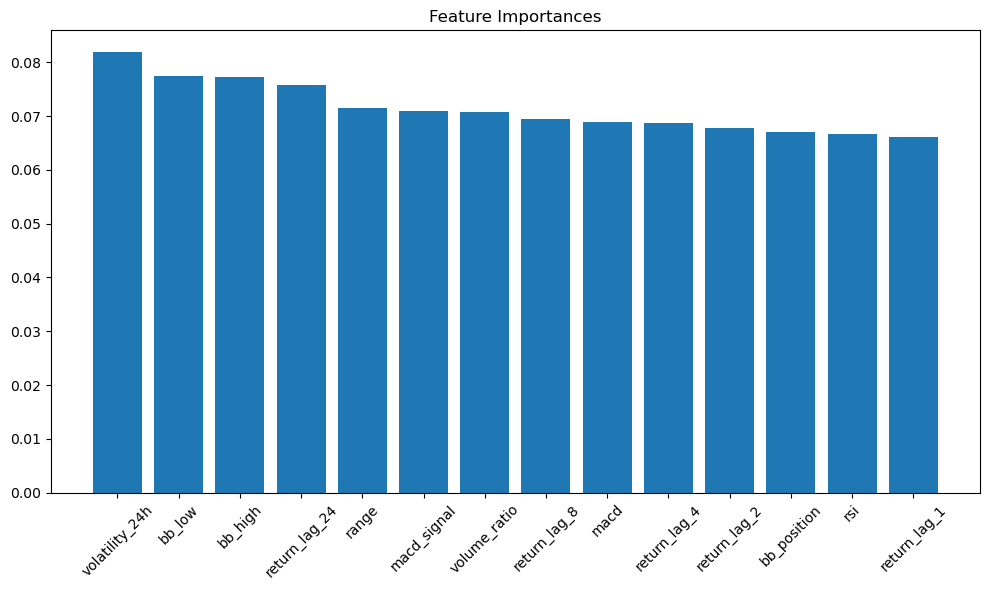

In [1]:
# %% [markdown]
# # 03 - Model Training
# ## Training and comparing ML models

# %%
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from src import utils, config

# %%
# Load features data
df = pd.read_csv(config.FEATURES_DATA_PATH)
print(f"Data shape: {df.shape}")

# %%
# Prepare features and target
X = df[config.FEATURES]
y = df[config.TARGET]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Chronological split
train_size = int(len(df) * (1 - config.TEST_SIZE))
X_train, X_test = X_scaled[:train_size], X_scaled[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

# %%
# Model 1: Logistic Regression (Baseline)
lr = LogisticRegression(random_state=config.RANDOM_STATE)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

metrics_lr = utils.calculate_metrics(y_test, y_pred_lr, y_proba_lr)
print("Logistic Regression Metrics:")
for metric, value in metrics_lr.items():
    print(f"{metric}: {value:.4f}")

# Save model
utils.save_model(lr, config.LR_MODEL_PATH)

# %%
# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=config.RANDOM_STATE)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

metrics_rf = utils.calculate_metrics(y_test, y_pred_rf, y_proba_rf)
print("Random Forest Metrics:")
for metric, value in metrics_rf.items():
    print(f"{metric}: {value:.4f}")

# Save model
utils.save_model(rf, config.RF_MODEL_PATH)

# %%
# Model 3: XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=config.RANDOM_STATE)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

metrics_xgb = utils.calculate_metrics(y_test, y_pred_xgb, y_proba_xgb)
print("XGBoost Metrics:")
for metric, value in metrics_xgb.items():
    print(f"{metric}: {value:.4f}")

# Save model
utils.save_model(xgb, config.XGB_MODEL_PATH)

# %%
# Save all metrics
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [metrics_lr['accuracy'], metrics_rf['accuracy'], metrics_xgb['accuracy']],
    'Precision': [metrics_lr['precision'], metrics_rf['precision'], metrics_xgb['precision']],
    'Recall': [metrics_lr['recall'], metrics_rf['recall'], metrics_xgb['recall']],
    'ROC-AUC': [metrics_lr['roc_auc'], metrics_rf['roc_auc'], metrics_xgb['roc_auc']]
})

os.makedirs(os.path.dirname(config.METRICS_PATH), exist_ok=True)
results.to_csv(config.METRICS_PATH, index=False)
print(f"\nResults saved to {config.METRICS_PATH}")
print(results)

# %%
# Feature importance plot for Random Forest
utils.plot_feature_importance(rf, config.FEATURES, config.FIGURES_PATH)